<u>במדבר א</u>

ואלה שמות האנשים אשר יעמדו אתכם לראובן **אליצור** בן־שדיאור: לשמעון **שלמיאל** בן־צורישדי: ליהודה **נחשון** בן־עמינדב: ליששכר **נתנאל** בן־צוער: לזבולן **אליאב** בן־חלן: לבני יוסף לאפרים **אלישמע** בן־עמיהוד למנשה **גמליאל** בן־פדהצור: לבנימן **אבידן** בן־גדעוני: לדן **אחיעזר** בן־עמישדי: לאשר **פגעיאל** בן־עכרן: לגד **אליסף** בן־דועל: לנפתלי **אחירע** בן־עינן

In [ ]:
census = ["נחשון", "נתנאל", "אליאב", "אלישמע", "גמליאל", "אבידן", "אליצור", "שלמיאל", "אליסף", "אחיעזר", "פגעיאל", "אחירע"]

In [ ]:
census_ranked = [
    ["נחשון", 80],   # יהודה
    ["נתנאל", 76],   # יששכר
    ["אליאב", 73],   # זבולון
    ["אלישמע", 69],  # אפרים
    ["גמליאל", 65],  # מנשה
    ["אבידן", 62],   # בנימין
    ["אליצור", 58],  # ראובן
    ["שלמיאל", 55],  # שמעון
    ["אליסף", 51],   # גד
    ["אחיעזר", 47],  # דן
    ["פגעיאל", 44],  # אשר
    ["אחירע", 40],   # נפתלי
]

In [18]:
from dataclasses import dataclass
from typing import Optional
import re

# --- bidi-safe label formatting (number LTR, Hebrew RTL) ---
LRI = "\u2066"
RLI = "\u2067"
PDI = "\u2069"

def format_label(key: int, heb_name: str) -> str:
    return f"{LRI}{key}{PDI} ({RLI}{heb_name}{PDI})"

_INVIS = re.compile(r"[\u200e\u200f\u202a-\u202e\u2066-\u2069]")

@dataclass
class Node:
    key: int
    name: str
    left: Optional["Node"] = None
    right: Optional["Node"] = None

def bst_insert(root: Optional[Node], key: int, name: str) -> Node:
    if root is None:
        return Node(key, name)
    if key < root.key:
        root.left = bst_insert(root.left, key, name)
    else:
        root.right = bst_insert(root.right, key, name)
    return root

# --- printer (matches your screenshot style) ---
def show(root: Optional[Node]) -> None:
    if root is None:
        print("(empty)")
        return

    def _show(n: Node, prefix: str, is_tail: bool):
        print(prefix + ("└── " if is_tail else "├── ") + format_label(n.key, n.name))
        kids = [k for k in (n.left, n.right) if k is not None]  # left then right
        for i, child in enumerate(kids):
            _show(child, prefix + ("    " if is_tail else "│   "), i == len(kids) - 1)

    # print root, then force a continuing trunk "│   " under it
    print("└── " + format_label(root.key, root.name))
    kids = [k for k in (root.left, root.right) if k is not None]
    for i, child in enumerate(kids):
        _show(child, "│   ", i == len(kids) - 1)

# --- build EXACT bst from your target by using preorder insert order ---
items = [
    (75, "אלישמע"),
    (69, "אחיעזר"),
    (66, "אליסף"),
    (65, "אחירע"),
    (67, "פגעיאל"),
    (71, "אבידן"),
    (73, "גמליאל"),
    (81, "נחשון"),
    (77, "אליאב"),
    (79, "נתנאל"),
    (83, "שלמיאל"),
    (85, "אליצור"),
]

root = None
for k, name in items:
    root = bst_insert(root, k, name)

show(root)

└── ⁦75⁩ (⁧אלישמע⁩)
│   ├── ⁦69⁩ (⁧אחיעזר⁩)
│   │   ├── ⁦66⁩ (⁧אליסף⁩)
│   │   │   ├── ⁦65⁩ (⁧אחירע⁩)
│   │   │   └── ⁦67⁩ (⁧פגעיאל⁩)
│   │   └── ⁦71⁩ (⁧אבידן⁩)
│   │       └── ⁦73⁩ (⁧גמליאל⁩)
│   └── ⁦81⁩ (⁧נחשון⁩)
│       ├── ⁦77⁩ (⁧אליאב⁩)
│       │   └── ⁦79⁩ (⁧נתנאל⁩)
│       └── ⁦83⁩ (⁧שלמיאל⁩)
│           └── ⁦85⁩ (⁧אליצור⁩)


In [20]:
from dataclasses import dataclass
from typing import Optional, List
import re

# --- bidi-safe label formatting ---
LRI = "\u2066"
RLI = "\u2067"
PDI = "\u2069"

def format_label(key: int, heb_name: str) -> str:
    return f"{LRI}{key}{PDI} ({RLI}{heb_name}{PDI})"

_INVIS = re.compile(r"[\u200e\u200f\u202a-\u202e\u2066-\u2069]")
def vis_len(s: str) -> int:
    return len(_INVIS.sub("", s))

@dataclass
class Node:
    key: int
    name: str
    left: Optional["Node"] = None
    right: Optional["Node"] = None

def bst_insert(root: Optional[Node], key: int, name: str) -> Node:
    if root is None:
        return Node(key, name)
    if key < root.key:
        root.left = bst_insert(root.left, key, name)
    else:
        root.right = bst_insert(root.right, key, name)
    return root

def height_edges(root: Optional[Node]) -> int:
    if not root:
        return -1
    return 1 + max(height_edges(root.left), height_edges(root.right))

def build_full_levels(root: Optional[Node], h: int) -> List[List[Optional[Node]]]:
    levels: List[List[Optional[Node]]] = []
    cur = [root]
    for _ in range(h + 1):
        levels.append(cur)
        nxt = []
        for n in cur:
            if n is None:
                nxt.extend([None, None])
            else:
                nxt.extend([n.left, n.right])
        cur = nxt
    return levels

def ascii_bst_topdown_full(root: Optional[Node], *, level_gap: int = 2, pad: int = 1, shrink: int = 1) -> str:
    """
    Top-down, root centered, keeps empty child slots.
    Tighter layout via:
      - level_gap: vertical spacing (2 is tight)
      - pad: extra spacing inside each slot
      - shrink: reduce horizontal slot spacing by powers of two (1 halves width)
    """
    if root is None:
        return ""

    h = height_edges(root)
    levels = build_full_levels(root, h)

    # compute max visible label width
    lbls = [format_label(n.key, n.name) for lvl in levels for n in lvl if n is not None]
    max_w = max((vis_len(s) for s in lbls), default=1)

    # unit spacing between adjacent leaf slots must be >= (max_w+pad)/2 to prevent overlap
    unit = max(1, (max_w + pad + 1) // 2)

    def spread(d: int) -> int:
        # shrink reduces the exponent, halving width per +1
        return 2 ** max(0, (h - d - shrink))

    # canvas size
    width = (2 ** (h + 1) + 1) * unit + max_w + 2
    height = (h + 1) * level_gap + 1
    canvas = [[" " for _ in range(width)] for _ in range(height)]

    def put_text(row: int, col_center: int, text: str):
        w = vis_len(text)
        start = max(0, col_center - w // 2)
        c = start
        pending = ""
        last_c = None
        for ch in text:
            if _INVIS.match(ch):
                pending += ch
                continue
            if 0 <= row < height and 0 <= c < width:
                canvas[row][c] = pending + ch
                last_c = c
            pending = ""
            c += 1
        if pending and last_c is not None:
            canvas[row][last_c] += pending

    # fullwidth slashes so they don't become links
    SLASH_L, SLASH_R = "／", "＼"

    def x_center(d: int, p: int) -> int:
        return ((2 * p + 1) * spread(d)) * unit

    # labels
    for d, lvl in enumerate(levels):
        r = d * level_gap
        for p, n in enumerate(lvl):
            if n is None:
                continue
            put_text(r, x_center(d, p), format_label(n.key, n.name))

    # edges
    for d in range(h):
        r0 = d * level_gap
        r1 = (d + 1) * level_gap
        steps = r1 - r0 - 1
        if steps <= 0:
            continue

        lvl = levels[d]
        nxt = levels[d + 1]
        for p, n in enumerate(lvl):
            if n is None:
                continue
            pc = x_center(d, p)

            lp = 2 * p
            if lp < len(nxt) and nxt[lp] is not None:
                cc = x_center(d + 1, lp)
                for i in range(steps):
                    rr = r0 + 1 + i
                    t = (i + 1) / (steps + 1)
                    col = round(pc + (cc - pc) * t)
                    if canvas[rr][col] == " ":
                        canvas[rr][col] = SLASH_L

            rp = 2 * p + 1
            if rp < len(nxt) and nxt[rp] is not None:
                cc = x_center(d + 1, rp)
                for i in range(steps):
                    rr = r0 + 1 + i
                    t = (i + 1) / (steps + 1)
                    col = round(pc + (cc - pc) * t)
                    if canvas[rr][col] == " ":
                        canvas[rr][col] = SLASH_R

    return "\n".join("".join(row).rstrip() for row in canvas).rstrip()


# ---- use it ----
items = [
    (75, "אלישמע"),
    (69, "אחיעזר"),
    (66, "אליסף"),
    (65, "אחירע"),
    (67, "פגעיאל"),
    (71, "אבידן"),
    (73, "גמליאל"),
    (81, "נחשון"),
    (77, "אליאב"),
    (79, "נתנאל"),
    (83, "שלמיאל"),
    (85, "אליצור"),
]

root = None
for k, name in items:
    root = bst_insert(root, k, name)

print(ascii_bst_topdown_full(root, level_gap=2, pad=1, shrink=1))

                   ⁦75⁩ (⁧אלישמע⁩)
                  ／           ＼
       ⁦69⁩ (⁧אחיעזר⁩)             ⁦81⁩ (⁧נחשון⁩)
         ／     ＼                 ／     ＼
 ⁦66⁩ (⁧אליסף⁩)  ⁦71⁩ (⁧אבידן⁩)  ⁦77⁩ (⁧אליאב⁩)  ⁦83⁩ (⁧שלמיאל⁩)
      ／     ＼                 ＼                 ＼                 ＼
 ⁦65⁩ (⁧אחירע⁩)  ⁦67⁩ (⁧פגעיאל⁩)             ⁦73⁩ (⁧גמליאל⁩)             ⁦79⁩ (⁧נתנאל⁩)              ⁦85⁩ (⁧אליצור⁩)


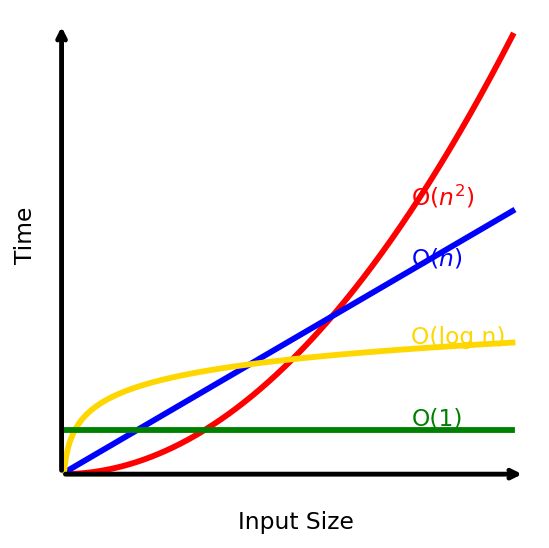

In [12]:
import numpy as np
import matplotlib.pyplot as plt

n_max = 200
n = np.linspace(1, n_max, 800)

y_const_raw = np.ones_like(n)
y_log_raw   = np.log2(n)
y_lin_raw   = n
y_quad_raw  = n**2

target_const = 1.0
target_log   = 3.0
target_lin   = 6.0
target_quad  = 10.0

y_const = y_const_raw * target_const
y_log   = y_log_raw  * (target_log / y_log_raw.max())
y_lin   = y_lin_raw  * (target_lin / y_lin_raw.max())
y_quad  = y_quad_raw * (target_quad / y_quad_raw.max())

fig, ax = plt.subplots(figsize=(4, 4), dpi=140)

ax.plot(n, y_quad,  color="red",        lw=3)
ax.plot(n, y_lin,   color="blue",       lw=3)
ax.plot(n, y_log,   color="gold",       lw=3)
ax.plot(n, y_const, color="green",      lw=3)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
y_max = target_quad * 1.05
ax.set_xlim(0, n_max * 1.05)
ax.set_ylim(0, y_max)
ax.annotate(
    "", xy=(n_max * 1.03, 0), xytext=(0, 0),
    arrowprops=dict(arrowstyle="->", lw=2.5, color="black"),
    clip_on=False
)
ax.annotate(
    "", xy=(0, y_max * 0.98), xytext=(0, 0),
    arrowprops=dict(arrowstyle="->", lw=2.5, color="black"),
    clip_on=False
)
ax.text(n_max * 0.52, -y_max * 0.08, "Input Size", ha="center", va="top", fontsize=12)
ax.text(-n_max * 0.08, y_max * 0.52, "Time", ha="center", va="center", rotation=90, fontsize=12)
x_label = 155
i = np.searchsorted(n, x_label)

ax.text(n[i], y_quad[i],  r"O($n^2$)", color="red",        fontsize=12, va="bottom")
ax.text(n[i], y_lin[i],   r"O($n$)",   color="blue",       fontsize=12, va="bottom")
ax.text(n[i], y_log[i],   r"O(log n)", color="gold",       fontsize=12, va="bottom")
ax.text(n[i], y_const[i], r"O(1)",     color="green",      fontsize=12, va="bottom")

plt.tight_layout()
plt.show()

In [15]:
class BST:
    def __init__(self, value):
        self.value = value
        self.left = None
        self.right = None

    def insert(self, value):
        if value < self.value:
            if self.left is None:
                self.left = BST(value)
            else:
                self.left.insert(value)
        else:
            if self.right is None:
                self.right = BST(value)
            else:
                self.right.insert(value)
        return self

    def remove(self, value):
        if value < self.value:
            if self.left is not None:
                self.left = self.left.remove(value)
            return self

        if value > self.value:
            if self.right is not None:
                self.right = self.right.remove(value)
            return self
        
        if self.left is None and self.right is None:
            return None
        if self.left is None:
            return self.right
        if self.right is None:
            return self.left

        succ = self.right._min_value()
        self.value = succ
        self.right = self.right.remove(succ)
        return self

    def _min_value(self):
        n = self
        while n.left is not None:
            n = n.left
        return n.value


    def rekey(self, old_value, new_value):
        root = self.remove(old_value)
        if root is None:
            return BST(new_value)
        root.insert(new_value)
        return root


def print_tree(node, indent="", is_left=None):
    if node is None:
        return
    print_tree(node.right, indent + "    ", False)
    if is_left is None:
        print(f"{indent}{node.value}")
    else:
        print(f"{indent}{'└──' if is_left else '┌──'}{node.value}")
    print_tree(node.left, indent + "    ", True)